In [3]:
import verovio
import json

from typing import Literal, TypedDict

# A TypedDict specifies a dictionary that must have these keys, and each key must have a specific value.
class StaffDefinition(TypedDict):
    clef: str
    keysig: str | None
    metersig: str

type Duration = int
# Accidentals can only be one of three values, so we use the "Literal" type to narrow it down
type Accidental = Literal["+", "-", "x"]

class Note(TypedDict):
    pname: str
    oct: int
    dur: Duration
    accid: Accidental | None
    dot: bool
    beamed: bool

class Rest(TypedDict):
    dur: Duration
    dot: bool

class Measure(TypedDict):
    events: list[Note | Rest]

class Score(TypedDict):
    definition: StaffDefinition
    measures: list[Measure]


def render(input: Score) -> str:
    """Takes a Score object and produces an image using Verovio.
        Internally, it takes our encoding format and produces a Plaine and Easie encoding
        since Verovio knows how to render that.
    """
    tk = verovio.toolkit()
    tk.setInputFrom("pae")
    tk.setOptions({
        "footer": "none",
        "header": "none",
        "adjustPageHeight": True
    })

    note_data: str = ""
    for measure in input["measures"]:
        events = measure["events"]
        for i, event in enumerate(measure["events"]):
            # We need to figure out beaming groups. Look at the previous, current, and next events.
            prev = events[i - 1] if i > 0 else None
            next = events[i + 1] if i < len(events) - 1 else None

            # If the previous one isn't beamed, but this one is, then we insert an open beam character
            if event.get("beamed", False) is True:
                # Now check if we either a) don't have a previous note, or b) we do have a previous note, but it wasn't beamed.
                # Only then do we need to emit a beam group.
                if not prev or prev and prev.get("beamed", False) is False:
                    note_data += "{"

            # Process the note data normally.
            note_data += _process_event(event)

            # If the next one isn't beamed, but this one is, then we insert a close beam character
            if event.get("beamed", False) is True and (next and next.get("beamed", False) is False):
                note_data += "}"

        # After all events have been processed, but before we end the
        # measure loop, add a barline.
        note_data += "/"

    pae_dict: dict = {
        "clef": input["definition"]["clef"],
        "keysig": input["definition"]["keysig"],
        "timesig": input["definition"]["metersig"],
        "data": note_data
    }

    tk.loadData(json.dumps(pae_dict))
    svg_out: str = tk.renderToSVG()
    return svg_out


def _process_event(ev: Note | Rest) -> str:
    pae_event: str = ""
    # Both have a duration, so we can deal with that here.
    dur: str = str(ev["dur"])

    # Both notes and rests can have a dot
    dot_value = ev["dot"]
    dot_pae: str = ""
    if dot_value:
        dot_pae = "."

    if "pname" not in ev:
        # only notes have pnames, so this is a rest
        pae_event += dur
        pae_event += dot_pae
        pae_event += "-"
        return pae_event

    # The octave indicator is ' for octave 4+, and , for <4. 
    # We can multiply a string to get that many copies of it.
    # So for the 4th octave we get 4 - 3 = 1 * '; for the 5th octave: 5 - 3 = 2*', and so on. 
    # Same for the lower octaves. 
    if ev["oct"] >= 4:
        num_oct = "'" * (ev["oct"] - 3)
    else:
        num_oct = "," * (ev["oct"] - 2)

    pae_event += num_oct

    # Add the duration.
    pae_event += dur
    pae_event += dot_pae

    # We need to convert accidentals
    accid_val: str | None = ev["accid"]
    # dictionaries are handy ways of mapping one value to another.
    accid_map: dict = {
        "x": "xx",
        "+": "x",
        "-": "b"
    }
    if accid_val:
        # It's not None
        pae_event += accid_map[accid_val]

    pname_val: str = ev["pname"]
    pae_event += pname_val

    return pae_event


def make_staff_definition(line_input: str) -> StaffDefinition:
    """ Parses a line like this: 
        
        -- c:G-2 k:1f t:4/4

        into a StaffDefinition dictionary.
    """
    # Split the line into different tokens
    toks: list[str] = line_input.split(" ")
    # Let's declare some variables
    this_clef: str
    this_keysig: str
    this_metersig: str

    for tok in toks:
        if tok == "--":
            # Skip the leader
            continue
        # All other values are "sth:sth" so split on the colon.
        tok_pair: list[str] = tok.split(":")
        tok_type: str = tok_pair[0]
        tok_val: str = tok_pair[1]
        
        if tok_type == "c":
            # Clef
            this_clef = tok_val
        elif tok_type == "k":
            # Key Signature
            this_keysig = tok_val
        elif tok_type == "t":
            # Time signature
            this_metersig = tok_val
        else:
            print(f"Unknown token type {tok_type} with value {tok_val}")
            continue

    return {
        "clef": this_clef,
        "keysig": this_keysig,
        "metersig": this_metersig
    }


def make_measure(line_input: str) -> Measure:
    # We don't need the start and end brackets in the encoding
    # Splitting on spaces gives us a list of tokens.
    toks: list[str] = line_input.strip("[]").split(" ")

    # Build our list of events
    events: list[Note | Rest] = []
    in_beam: bool = False

    for tok in toks:
        # Each token is an event. Try to figure out what kind of event.
        # we can create a list of individual characters in the event
        tok_list = list(tok)
        if 'r' in tok_list:
            # We have a rest. Format: r[dur][dot?]
            num_dots: int = tok_list.count(".")
            # Duration is always the second entry
            dur_val = tok_list[1]
            a_rest: Rest = {
                "dur": int(dur_val),
                "dot": True if num_dots > 0 else False
            }
            events.append(a_rest)
            continue
            

        # if not, we assumen we have a note. 
        #  Format: {4-B8.}
        #    { -- start beam (optional)
        #    4 -- octave
        #    - -- flat (optional)
        #    B -- pname
        #    8 -- duration
        #    . -- dot (optional)
        #    } -- end beam (optional)

        # The beam status is tracked outside of the loop, so it will be set to True when a { is encountered, and will stay that way
        # until we encounter a }, which will set it to False.
        if "{" in tok_list:
            in_beam = True

        a_note: Note = create_note(tok_list, in_beam)
        events.append(a_note)

        # Be sure to set not-in-beam after processing the note, since the note itself is still in the beam.
        if "}" in tok_list:
            in_beam = False

    return {
        "events": events
    }


def create_note(token_list: list[str], in_beam: bool) -> Note:
    """
        Complex logic for creating a note from a list of tokens. Since we track
        the beam status externally, it needs to be passed in as an argument.
    """
    # First, remove any braces since we don't need them and they just confuse things:
    cleaned_toks: list[str] = [t for t in token_list if t not in ("{", "}")]
    # "pop()" will return the thing at a given index, but then remove it from the list.
    # This makes it good for setting something and then removing it from consideration.
    oct: int = int(cleaned_toks.pop(0))
    # Negative 1 is an easy way to get the last item in a list.

    # The last one is either a duration or a dot.
    dur_or_dot: str = cleaned_toks.pop(-1)
    dot: bool = False
    dur: int
    if dur_or_dot == ".":
        dot = True
        # If we have a dot, then the last item is now a duration. Pop it off.
        dur = int(cleaned_toks.pop(-1))
    else:
        # If it wasn't a dot, it was a duration.
        dur = int(dur_or_dot)
    
    # The pname is now the last item in the list, so we can get that.
    pname: str = cleaned_toks.pop(-1)
    # Finally, all we should have left is either an empty list, or a list with an accidental in it.
    accid: str | None = None
    if len(cleaned_toks) > 0:
        accid_t = cleaned_toks[0]
        # Ensure it's one of the values we accept for accidentals
        if accid_t in ("+", "-", "x"):
            accid = accid_t

    return {
        "accid": accid,
        "beamed": in_beam,
        "dur": dur,
        "dot": dot,
        "oct": oct,
        "pname": pname,
    }


def main() -> bool:
    # 1. Read the file and extract the lines
    with open("sample-encodings/encoding.txt") as my_encoding:
        # Use the `readlines()` method on my_encoding to get a list of the lines in a file.
        file_contents: list[str] = my_encoding.readlines()

    # 2. When you read lines in, you will get the end of line character (\n)
    # and any empty lines. This list comprehension will also use the truthiness of an empty
    # string to filter out blank lines, leaving only the contents.
    cleaned_contents: list[str] = [l.strip() for l in file_contents if l.strip()]

    staff_def: StaffDefinition
    measures: list[Measure] = []

    for line in cleaned_contents:
        if line.startswith("--"):
            staff_def = make_staff_definition(line)
        elif line.startswith("["):
            measures.append(make_measure(line))
        else:
            # If it doesn't match either, what should we do??
            print("Oh dear, I don't know what kind of line this is!")

    # 3. Create your score from the processed values
    encoding: Score = {
        "definition": staff_def,
        "measures": measures
    }

    # 4. Pass it over to Verovio to render
    rendered_svg = render(encoding)
    # print(rendered_svg)
    from IPython.display import SVG, display
    display(SVG(rendered_svg))
    return True


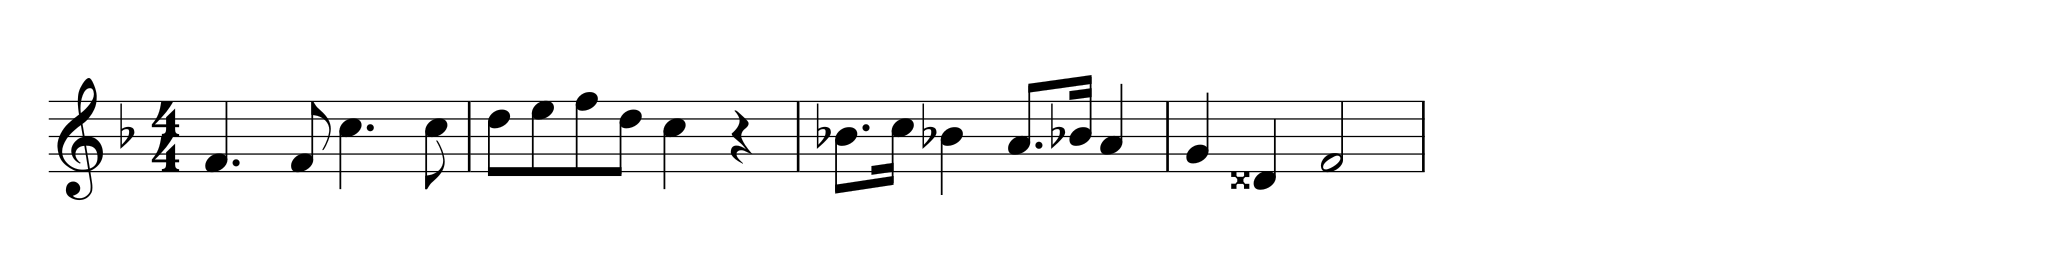

True

In [4]:
main()